Note: you may need to restart the kernel to use updated packages.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 22ms/step - accuracy: 0.9609 - loss: 0.1273 - val_accuracy: 0.9850 - val_loss: 0.0417
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9867 - loss: 0.0429 - val_accuracy: 0.9885 - val_loss: 0.0364
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.9908 - loss: 0.0285 - val_accuracy: 0.9883 - val_loss: 0.0350
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9934 - loss: 0.0208 - val_accuracy: 0.9893 - val_loss: 0.0317
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9951 - loss: 0.0150 - val_accuracy: 0.9878 - val_loss: 0.0385
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9959 - loss: 0.0128 - val_accuracy: 0.9919 - val_loss: 0.0308
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9965 - loss: 0.0101 - val_accuracy: 0.9919 - val_loss: 0.0342
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9973 -

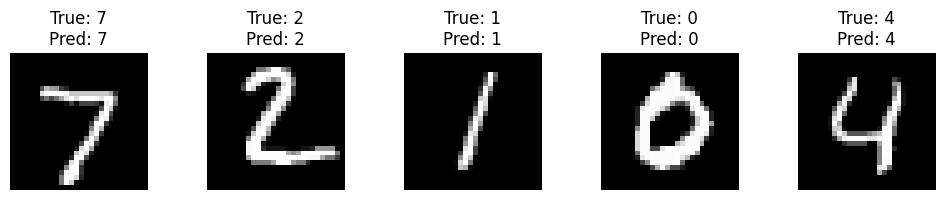

In [4]:
# If TensorFlow (and Keras) are not installed in this kernel/environment, install them using the notebook magic.
# This ensures the packages are available to the running Jupyter kernel (required to fix
# "Import ... could not be resolved" in many VS Code/Jupyter setups).
# Install both tensorflow and keras to satisfy linters and runtime in various environments.
%pip install -q tensorflow keras

import tensorflow as tf
# Use tf.keras attributes instead of direct from tensorflow.keras imports.
# This avoids some linters/editors complaining with "Expected module name"
# while still providing the same symbols used later in the notebook.
Sequential = tf.keras.Sequential
Conv2D = tf.keras.layers.Conv2D
MaxPooling2D = tf.keras.layers.MaxPooling2D
Flatten = tf.keras.layers.Flatten
Dense = tf.keras.layers.Dense
import matplotlib.pyplot as plt
import numpy as np

# 1. Load and Preprocess Data
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize images to 0-1 range (Crucial step for Neural Networks)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape data to include the channel dimension (28x28x1 for grayscale images)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

# 2. Build the CNN Model Architecture
model = Sequential([
    # Input layer and first convolutional block
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    
    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Flatten the 2D feature maps to a 1D vector for the Dense layers
    Flatten(),
    
    # Dense (fully connected) layers
    Dense(128, activation='relu'),
    Dense(10, activation='softmax') # Output layer: 10 units for 10 digits, softmax for probability distribution
])

# Display model structure (Include screenshot of this in your report)
model.summary()


# 3. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # Use sparse loss because y labels are integers (0-9)
              metrics=['accuracy'])

# 4. Train the Model
history = model.fit(X_train, y_train, 
                    epochs=10, 
                    validation_data=(X_test, y_test))

# 5. Evaluate and Check Goal (>95% Accuracy)
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {accuracy:.4f}")
# Deliverable check: Ensure accuracy is > 0.95 and include a screenshot of the training/evaluation output.

# 6. Visualize Predictions on 5 Sample Images
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

# Select the first 5 test images for visualization
n_samples = 5
plt.figure(figsize=(10, 2))
for i in range(n_samples):
    plt.subplot(1, n_samples, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test[i]}\nPred: {predicted_classes[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()
# Deliverable check: Include a screenshot of this plot showing 5 sample predictions in your PDF report.

model.save('mnist_cnn_model.h5')